# Life-Like Network Automata — the basics

A **Life-Like Network Automaton (LLNA)** generalises Conway's Game of Life from a
grid to an arbitrary network. Every node carries a binary state (dead/alive) and
all nodes update synchronously in discrete time. What a node does next depends on
two things only:

1. its **own state**, and
2. the **density** $\rho \in [0, 1]$ of alive nodes among its neighbours.

The local update rule is a triplet $(R, B, S)$:

- the **resolution** $R$ divides the density range $[0,1]$ into $R$ subintervals;
- the **born set** $B \subseteq \{0,\dots,R-1\}$: a *dead* node becomes alive
  iff its neighbourhood density falls in an enabled interval;
- the **survive set** $S$: an *alive* node stays alive iff the density falls in an
  enabled interval. Everything else dies.

A rule is written `R{r}B{beta}S{sigma}` where $\beta = \sum_{i \in B} 2^i$ and
$\sigma = \sum_{i \in S} 2^i$, or in short as $\phi^{R}_{\beta,\sigma}$.

In [1]:
import igraph as ig
import matplotlib.pyplot as plt
import numpy as np
import torch as tc

from llna import LLNA
from llna.networks import create_2d_torus_lattice

## Game of Life as an LLNA

On a degree-8 torus, GoL's "born on 3 neighbours, survive on 2 or 3" becomes
resolution 9 with $B=\{3\}$, $S=\{2,3\}$ (the interval $k$ contains exactly the
density $k/8$ for degree-8 nodes). The `diagram` method draws the rule; the dashed
lines mark the densities a degree-8 node can actually attain.

R9B8S12 = $\phi^{9}_{8,12}$


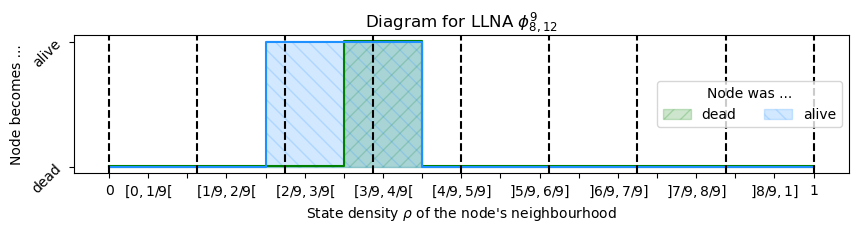

In [2]:
gol = LLNA(9, [3], [2, 3], iso=True)
print(gol, "=", gol.__str__(latex=True))
fig, ax = gol.diagram(degree=8)

## Interval encoding — where a density lands

`iso=True` (odd $R$ only) uses intervals arranged symmetrically around $\rho=1/2$,
so that the density complement $\rho \to 1-\rho$ mirrors the interval index — the
encoding that makes black-white rule equivalences exact (notebook 02). The middle
interval is closed on both sides; the non-iso variant simply uses
$[k/R, (k+1)/R)$ with $\rho=1$ folded into the top interval.

In [3]:
rhos = tc.linspace(0, 1, 9).unsqueeze(0)
onehot = gol.interval_encoding(rhos)
for rho, interval in zip(rhos[0], onehot[0].argmax(axis=1)):
    print(f"rho = {rho:.3f} -> interval {int(interval)}")

rho = 0.000 -> interval 0
rho = 0.125 -> interval 1
rho = 0.250 -> interval 2
rho = 0.375 -> interval 3
rho = 0.500 -> interval 4
rho = 0.625 -> interval 5
rho = 0.750 -> interval 6
rho = 0.875 -> interval 7
rho = 1.000 -> interval 8


## Running the automaton

Graphs come from `igraph`; the model consumes a **directed edge tensor** `[2, M]`
(both directions for undirected graphs). `forward(E, h0, T)` evolves `L` initial
configurations at once and returns a `[L, T+1, N]` trajectory tensor.

Below: a glider on a 12x12 torus — after 4 steps it has moved one cell
diagonally, exactly as on Conway's grid.

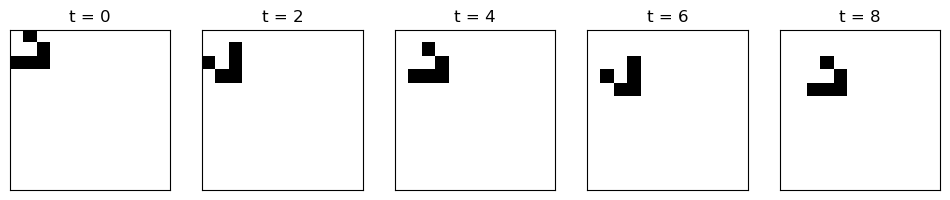

In [4]:
L_side = 12
graph = create_2d_torus_lattice(L_side, degree=8)
directed = graph.copy()
directed.to_directed()
E = tc.tensor(directed.get_edgelist(), dtype=tc.long).T

glider = np.zeros((L_side, L_side), dtype=np.int64)
for y, x in [(0, 1), (1, 2), (2, 0), (2, 1), (2, 2)]:
    glider[y, x] = 1

trajectory = gol.forward(E, tc.tensor(glider.reshape(1, -1)), T=8).numpy()[0]

fig, axes = plt.subplots(1, 5, figsize=(12, 2.6))
for ax, t in zip(axes, [0, 2, 4, 6, 8]):
    ax.imshow(trajectory[t].reshape(L_side, L_side), cmap="Greys")
    ax.set_title(f"t = {t}")
    ax.set_xticks([]), ax.set_yticks([])

## Ensembles and density curves

The batch dimension makes ensemble experiments one call: evolve many random
initial configurations ("soups") together and look at the global state density
$\langle h \rangle$ over time.

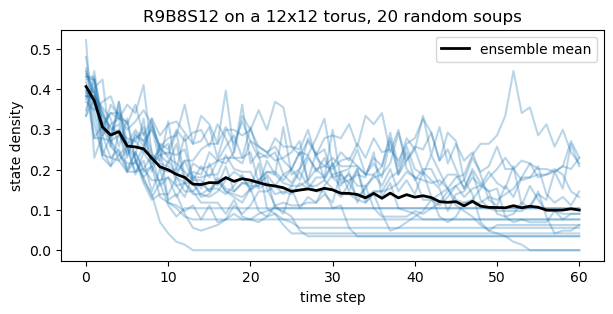

In [5]:
rng = np.random.default_rng(0)
soups = (rng.random((20, L_side * L_side)) < 0.4).astype(np.int64)
densities = gol.forward(E, tc.tensor(soups), T=60).numpy().mean(axis=2)

plt.figure(figsize=(7, 3))
plt.plot(densities.T, color="tab:blue", alpha=0.3)
plt.plot(densities.mean(axis=0), color="k", lw=2, label="ensemble mean")
plt.xlabel("time step"), plt.ylabel("state density"), plt.legend()
plt.title(f"{gol} on a {L_side}x{L_side} torus, 20 random soups");

## Where to go next

- **`02_rule_space.ipynb`** — the rule space, equivalences, and genotype metrics
  (Hamming weight, Boolean sensitivity).
- **`03_robustness_metrics.ipynb`** — defects, Jacobians, Lyapunov spectra,
  Derrida maps, and running large sweeps with `llna sweep`.
- `llna.visual` has ready-made animation helpers
  (`make_animation_object`, `make_igraph_animation`).